# NEXRAD derived radar products

Each WSR-88D radar's product generator turns every volume scan into dozens of
derived Level III products: super-resolution reflectivity and velocity at
each tilt, dual-polarization moments, echo tops, precipitation totals, and
detection tables such as mesocyclones and storm tracks. The Unidata feed
archives them to NOAA's public `unidata-nexrad-level3` S3 bucket, one small
binary file per product per volume scan, since 30 March 2020.

This walkthrough pulls thirty minutes of three products from the Oklahoma
City radar (KTLX) on the afternoon of 6 May 2024 and looks at what arrives.
usdata has no Level III reader, so it reads the files' fixed headers with the
standard library and draws a timeline of what the archive holds. It needs
only usdata and matplotlib, downloads 16 files (about 50 kB), and runs in a
few seconds.

In [1]:
import struct
from datetime import UTC, date, datetime, timedelta
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

import usdata
from usdata import cite_lockfile, pull, verify
from usdata.readers import UnsupportedFormat

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; pandas {pd.__version__}")

Executed (UTC): 2026-09-24T06:10:58+00:00
usdata 0.26.0; pandas 3.0.6


## Select

The manifest names one radar, `KTLX`, three product codes, and a window of
scan times, inclusive at both ends: 20:30 to 21:00 UTC on 6 May 2024. The
products are enhanced echo tops (`EET`), mesocyclone detections (`NMD`), and
storm tracking information (`NST`). `products` is required and checked
against the supported codes before any request; a geographic query or
`nearest` could name the radar instead of `site`. A window spans at most 31
days.

In [2]:
print(manifest.read_text())

name: ktlx-derived-products
sources:
  - dataset: noaa:nexrad-level3
    start: 2024-05-06T20:30:00Z
    end: 2024-05-06T21:00:00Z
    params:
      site: KTLX
      products: [NMD, NST, EET]



## What arrives

Each file is named `SITE_PRODUCT_YYYY_MM_DD_HH_MM_SS`, where the site drops
the first letter of its ICAO id (`TLX` for `KTLX`) and the time is the volume
scan's start in UTC. The committed `dataset.lock.json` pins every file's S3
URL and checksum, so a pull restores exactly these bytes.

In [3]:
result = pull(manifest)
files = pd.DataFrame(
    {
        "product": item.asset.id.split("_")[1],
        "scan_utc": item.asset.time.start,
        "bytes": item.provenance.size,
        "file": item.path.name,
    }
    for item in result.fetched
)
print("Files:", len(files), "· bytes:", f"{files.bytes.sum():,}")
print("Source:", result.fetched[0].provenance.source_url.rsplit("/", 1)[0] + "/")
print(
    "Retrieved (UTC):",
    min(i.provenance.retrieved_at for i in result.fetched).isoformat(timespec="seconds"),
)
print("First checksum:", result.fetched[0].provenance.checksum)
files.groupby("product").agg(
    files=("file", "size"),
    first=("scan_utc", "min"),
    last=("scan_utc", "max"),
    min_bytes=("bytes", "min"),
    max_bytes=("bytes", "max"),
)

Files: 16 · bytes: 49,432
Source: s3://unidata-nexrad-level3/
Retrieved (UTC): 2026-09-24T06:10:58+00:00
First checksum: sha256:9ded5d4007d9d4e28e2187bae6d891e047b9a62633b198cff427ea38cb83e528


,files,first,last,min_bytes,max_bytes
product,,,,,
EET,6,2024-05-06 20:34:35+00:00,2024-05-06 20:59:43+00:00,2759,3247
NMD,5,2024-05-06 20:42:46+00:00,2024-05-06 20:59:43+00:00,150,150
NST,5,2024-05-06 20:42:46+00:00,2024-05-06 20:59:43+00:00,5726,6666


## Open

`open()` raises `UnsupportedFormat`: there is no Level III reader, and the
message names Py-ART as a decoder for `item.path`.

In [4]:
try:
    result.fetched[0].open()
except UnsupportedFormat as error:
    print(error)

NEXRAD Level III products have no usdata reader; open fetched.path with Py-ART (pyart.io.read_nexrad_level3) or another Level III decoder


The front of every file is fixed, though, and says what the file is without a
decoder. Two text lines of WMO header name the bulletin, the issuing office,
and the product and site. Then comes the binary message header and product
description block, big-endian: the numeric product code, the radar's
position, its operating mode and volume coverage pattern (VCP), and the
volume scan's start. Dates count days from 1 January 1970 as day 1, and times
are seconds after midnight UTC. Everything after that, the product's own
data, may be compressed and needs a decoder.

In [5]:
def level3_header(path: Path) -> dict:
    """Identity fields from a Level III file's WMO header and product description block."""
    data = path.read_bytes()
    wmo, product_line, rest = data.split(b"\r\r\n", 2)
    code, _, _, length = struct.unpack(">hhii", rest[:12])
    fields = struct.unpack(">hiihhhhhhhi", rest[18:46])
    _, lat, lon, height, _, mode, vcp, _, volume, scan_day, scan_seconds = fields
    scan = datetime.combine(date(1969, 12, 31), datetime.min.time(), UTC) + timedelta(
        days=scan_day, seconds=scan_seconds
    )
    return {
        "wmo": wmo.decode(),
        "product_line": product_line.decode(),
        "code": code,
        "message_bytes": length,
        "radar_lat": lat / 1000,
        "radar_lon": lon / 1000,
        "height_ft": height,
        "mode": {1: "clear air", 2: "precipitation"}.get(mode, mode),
        "vcp": vcp,
        "volume_number": volume,
        "volume_start": scan,
    }


headers = pd.DataFrame(level3_header(item.path) for item in result.fetched)
headers["name_matches_header"] = headers.volume_start.eq(files.scan_utc)
headers.drop_duplicates("code")[
    ["wmo", "product_line", "code", "radar_lat", "radar_lon", "mode", "vcp", "volume_start"]
]

,wmo,product_line,code,radar_lat,radar_lon,mode,vcp,volume_start
0,SDUS74 KOUN 062034,EETTLX,135,35.333,-97.278,clear air,35,2024-05-06 20:34:35+00:00
6,SDUS34 KOUN 062042,NMDTLX,141,35.333,-97.278,precipitation,212,2024-05-06 20:42:46+00:00
11,SDUS34 KOUN 062042,NSTTLX,58,35.333,-97.278,precipitation,212,2024-05-06 20:42:46+00:00


In [6]:
print("Every file's name matches its header's scan start:", bool(headers.name_matches_header.all()))
print(
    "Operating modes:", headers["mode"].unique().tolist(), "· VCPs:", headers.vcp.unique().tolist()
)
print("File bytes minus message bytes:", sorted((files.bytes - headers.message_bytes).unique()))

Every file's name matches its header's scan start: True
Operating modes: ['clear air', 'precipitation'] · VCPs: [35, 212]
File bytes minus message bytes: [np.int64(30)]


## A first look

Every file the archive holds for the window, one row per product, sized by
its bytes.

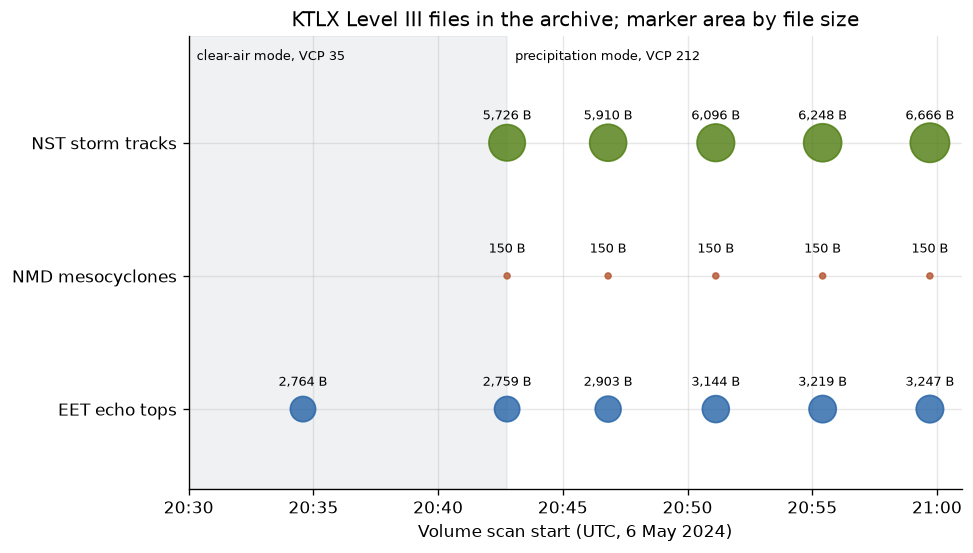

In [7]:
colors = {"EET": "#2563a6", "NMD": "#b45631", "NST": "#4d7c0f"}
fig, ax = plt.subplots(layout="constrained")
for row, (product, group) in enumerate(files.groupby("product")):
    ax.scatter(
        group.scan_utc,
        [row] * len(group),
        s=group.bytes / 12,
        color=colors[product],
        alpha=0.8,
        zorder=3,
    )
    for scan, size in zip(group.scan_utc, group.bytes, strict=True):
        ax.annotate(
            f"{size:,} B",
            (scan, row),
            xytext=(0, 14),
            textcoords="offset points",
            ha="center",
            fontsize=8,
        )
switch = headers.loc[headers["mode"] == "precipitation", "volume_start"].min()
start = pd.Timestamp("2024-05-06 20:30", tz="UTC")
ax.axvspan(start, switch, color="#9ca3af", alpha=0.15)
ax.text(start, 2.65, "  clear-air mode, VCP 35", fontsize=8, va="center")
ax.text(switch, 2.65, "  precipitation mode, VCP 212", fontsize=8, va="center")
ax.set_yticks(range(3), ["EET echo tops", "NMD mesocyclones", "NST storm tracks"])
ax.set_ylim(-0.6, 2.8)
ax.set_xlim(start, pd.Timestamp("2024-05-06 21:01", tz="UTC"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=UTC))
ax.set(
    xlabel="Volume scan start (UTC, 6 May 2024)",
    title="KTLX Level III files in the archive; marker area by file size",
)
plt.show()

In [8]:
volumes = files.join(headers[["volume_number", "vcp", "mode"]])
print(volumes.loc[volumes["product"] == "EET", ["scan_utc", "volume_number", "vcp", "mode"]])
print("NMD and NST begin at", volumes.loc[volumes["product"] != "EET", "scan_utc"].min())
print("NMD sizes:", sorted(int(b) for b in files.loc[files["product"] == "NMD", "bytes"].unique()))

                   scan_utc  volume_number  vcp           mode
0 2024-05-06 20:34:35+00:00             30   35      clear air
1 2024-05-06 20:42:46+00:00             31  212  precipitation
2 2024-05-06 20:46:49+00:00             32  212  precipitation
3 2024-05-06 20:51:08+00:00             33  212  precipitation
4 2024-05-06 20:55:25+00:00             34  212  precipitation
5 2024-05-06 20:59:43+00:00             35  212  precipitation
NMD and NST begin at 2024-05-06 20:42:46+00:00
NMD sizes: [150]


The echo-top files carry consecutive volume numbers, so the archive holds
every volume from 20:34:35 on for that product. The 8.2-minute step after 20:34
is one clear-air volume (VCP 35); at 20:42:46 the radar switched to
precipitation mode (VCP 212) and volumes came about every four minutes. The
mesocyclone and storm-track files begin exactly at that switch, and there are
none for the clear-air volume at 20:34:35. The files alone cannot say whether
the radar did not produce them in clear-air mode or the feed did not capture
them. Every mesocyclone file is 150 bytes, a table with no detections in any
volume, while the storm-track files grow as storms are tracked through the
half hour.

## Pin and cite

`verify` checks every cached file against the lockfile's checksums. Keep the
manifest and lockfile with your analysis; the citation below is what a
methods section needs, and `usdata cite dataset.yaml` prints the same.

In [9]:
assert verify(manifest) == []
for citation in cite_lockfile(manifest):
    print(citation.as_text())

noaa:nexrad-level3
  NEXRAD on AWS was accessed on 2026-09-16 from https://registry.opendata.aws/noaa-nexrad
  homepage: https://registry.opendata.aws/noaa-nexrad/
  license: US Government Work (public domain)
  terms: https://www.noaa.gov/information-technology/open-data-dissemination
  retrieved: 2026-09-16; 16 checksummed assets (49,432 bytes) pinned by usdata 0.18.0
  sources: 1


## What was awkward

- There is no reader, and none of the extras supplies one. Anything past the
  header means installing Py-ART or another Level III decoder and opening
  `item.path` directly.
- Missing files are silent. The pull returns what the archive holds, and
  whether a product is missing for a volume takes the volume numbers or VCPs
  from each file's header. The Level III guide calls the late start of the
  detection products a feed gap; here it coincides with the radar's switch out
  of clear-air mode, which the files cannot distinguish.
- A 150-byte mesocyclone file looks like a failed download but is an empty
  detection table. Size is the only sign without a decoder.
- Keys drop the radar's first letter. The query says `KTLX`, but files and
  asset ids say `TLX`, so matching them to Level II volumes or radar lists
  means adding the letter back.
- The asset's time is one instant, the volume scan's start, although the
  product is only generated once the volume completes a few minutes later.

See the [Level III guide](https://docs.usdata.dev/providers/noaa-nexrad-level3/)
for every product code and its typical size, and the
[Level II walkthrough](https://usdata.dev/datasets/noaa/nexrad-level2/) for the
volume scans these products come from.